# Day/night compositing primitives

[`pyramids_eo.composites`](../reference/composites.md) implements the
`true_color_with_night_ir` chain: a daytime true-colour image, a night-time IR-cloud
image over a city-lights background, and a smooth cross-fade between them driven by the
Sun's geometry. This notebook builds that image **one primitive at a time** so you can
see what each does:

`solar_zenith_angle` -> `day_weight` -> `true_color` -> `night_ir` -> `static_image`
-> `alpha_overlay` -> `day_night_blend` -> `true_color_with_night_ir`.

Everything runs on a small **synthetic** lon/lat scene straddling the day/night
terminator - no external compositing library, no data download. (For an end-to-end story
with an eclipse umbra, see [the eclipse notebook](eclipse_day_night.ipynb).)

## Setup

Imports, matplotlib, and a fixed observation time.

In [1]:
import datetime as dt
import tempfile
from pathlib import Path

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from pyramids.dataset import Dataset

from pyramids_eo.composites import (
    alpha_overlay,
    day_night_blend,
    day_weight,
    night_ir,
    solar_zenith_angle,
    static_image,
    true_color,
    true_color_with_night_ir,
)

## The scene grid

A 120 x 160 lon/lat grid spanning a terminator: latitudes 70 -> 30 degN, longitudes
-40 -> 60 degE. We keep the 2-D `lat` / `lon` arrays around because the solar geometry
is computed per pixel from them.

In [2]:
rows, cols = 120, 160
lat = np.linspace(70, 30, rows)[:, None] * np.ones((1, cols))
lon = np.linspace(-40, 60, cols)[None, :] * np.ones((rows, 1))
when = dt.datetime(2026, 8, 12, 18, 0, tzinfo=dt.timezone.utc)
print("grid:", (rows, cols), "| time:", when.isoformat())

grid: (120, 160) | time: 2026-08-12T18:00:00+00:00


## `solar_zenith_angle` — the Sun's geometry

`solar_zenith_angle(time, lat=, lon=)` gives the per-pixel angle between the Sun and the
local vertical, in degrees, from the NOAA solar-position algorithm (0 = overhead,
90 = horizon/terminator, 180 = antisolar). This is the compositor's clock: it keys off
*where the Sun is*, not how bright a pixel looks.

In [3]:
sza = solar_zenith_angle(when, lat=lat, lon=lon)
print("SZA range (deg):", round(float(sza.min()), 1), "->", round(float(sza.max()), 1))

SZA range (deg): 46.9 -> 125.7


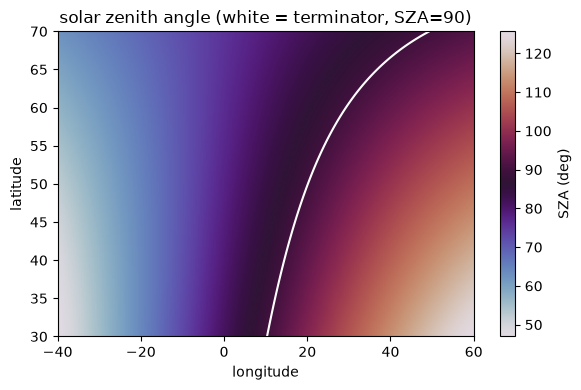

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(sza, cmap="twilight", extent=[-40, 60, 30, 70], aspect="auto")
ax.contour(
    np.linspace(-40, 60, cols),
    np.linspace(70, 30, rows),
    sza,
    levels=[90],
    colors="white",
)
ax.set_title("solar zenith angle (white = terminator, SZA=90)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
fig.colorbar(im, ax=ax, label="SZA (deg)")
fig.tight_layout()

## `day_weight` — the twilight ramp

`day_weight(sza)` turns the angle into a blend weight in `[0, 1]`: 1 in full day
(`sza <= lim_low`), 0 in full night (`sza >= lim_high`), and a smooth cos-space ramp
through the twilight band between. That ramp is what makes the day/night transition
gradual instead of a hard edge.

| argument | meaning | default |
| --- | --- | --- |
| `sza` | solar zenith angle (deg) | required |
| `lim_low` | fully-day threshold | 78 |
| `lim_high` | fully-night threshold | 88 |

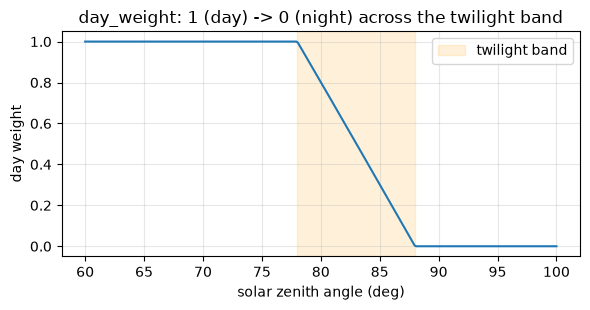

In [5]:
angles = np.linspace(60, 100, 300)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(angles, day_weight(angles))
ax.axvspan(78, 88, color="orange", alpha=0.15, label="twilight band")
ax.set_xlabel("solar zenith angle (deg)")
ax.set_ylabel("day weight")
ax.set_title("day_weight: 1 (day) -> 0 (night) across the twilight band")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## `true_color` — the day image

FCI / SEVIRI have no true green band, so `true_color(red, blue, nir)` synthesises one
with the CIMSS recipe `green = 0.45*red + 0.10*nir + 0.45*blue` and stacks
`[red, green, blue]` into a `(3, H, W)` RGB image. We feed it synthetic calibrated
reflectances.

In [6]:
rng = np.random.default_rng(0)
red = 0.30 + 0.10 * rng.random((rows, cols))
blue = 0.40 + 0.10 * rng.random((rows, cols))
nir = 0.50 + 0.10 * rng.random((rows, cols))
day = true_color(red, blue, nir, clip=True)
print("true_color shape:", day.shape)

true_color shape: (3, 120, 160)


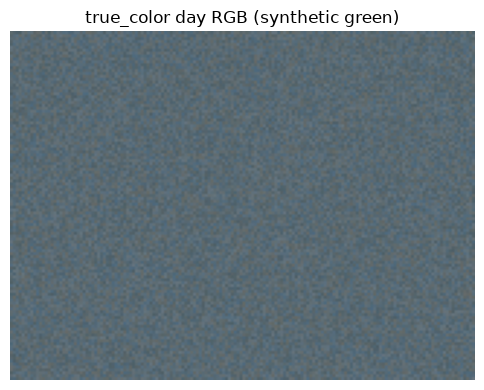

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.imshow(np.moveaxis(day, 0, -1))
ax.set_title("true_color day RGB (synthetic green)")
ax.axis("off")
fig.tight_layout()

## `night_ir` — the RGBA cloud image

At night there is no reflected light, so the reference look stacks three IR bands as RGB
and attaches an **alpha** channel from cloudiness: opaque over cold cloud tops,
transparent over clear sky (so the city lights show through the gaps).
`night_ir(red, green, blue, alpha=)` returns a `(4, H, W)` RGBA image.

In [8]:
yy, xx = np.mgrid[0:rows, 0:cols]
cloud = np.exp(-(((xx - 100) / 25) ** 2 + ((yy - 40) / 20) ** 2))
clouds = night_ir(0.85 * cloud, 0.75 * cloud, 0.65 * cloud, alpha=cloud)
print("night_ir shape (RGBA):", clouds.shape)

night_ir shape (RGBA): (4, 120, 160)


## `static_image` — the city-lights background

`static_image(source, like=)` loads a georeferenced raster (e.g. NASA Black Marble) and
warps it onto a target grid via pyramids' `align`, caching it locally when `source` is a
URL. To stay offline we write a synthetic city-lights raster to a temp file, then load it
back onto our scene grid - the same call you would make against a real Black Marble
GeoTIFF path or URL.

In [9]:
grid = Dataset.create_from_array(
    np.zeros((rows, cols)), top_left_corner=(-40.0, 70.0), cell_size=0.625, epsg=4326
)
lights = np.full((3, rows, cols), 0.04)
spark = rng.random((rows, cols)) > 0.985
lights[0][spark], lights[1][spark], lights[2][spark] = 1.0, 0.9, 0.6
lights_ds = Dataset.create_from_array(
    lights, top_left_corner=(-40.0, 70.0), cell_size=0.625, epsg=4326
)

tmp = Path(tempfile.mkdtemp()) / "city_lights.tif"
lights_ds.to_file(str(tmp))
background = static_image(str(tmp), like=grid)
print("loaded + aligned background:", background.shape, "epsg", background.epsg)

loaded + aligned background: (3, 120, 160) epsg 4326


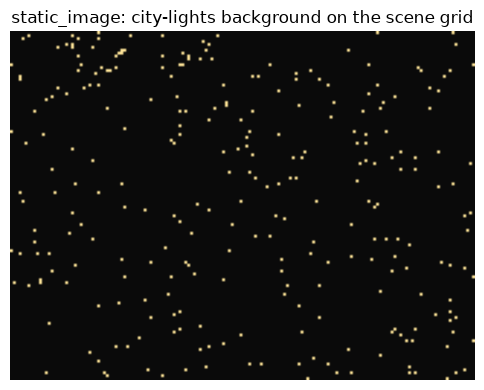

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.imshow(np.moveaxis(np.clip(background.read_array(), 0, 1), 0, -1))
ax.set_title("static_image: city-lights background on the scene grid")
ax.axis("off")
fig.tight_layout()

## `alpha_overlay` — clouds over the lights

`alpha_overlay(foreground, background)` is the "over" operator: it composites the RGBA
night-IR clouds onto the RGB city lights, so the lights stay visible through the
transparent (clear-sky) gaps and are hidden under opaque cloud. An RGB background yields
a 3-band RGB result.

night image shape: (3, 120, 160)


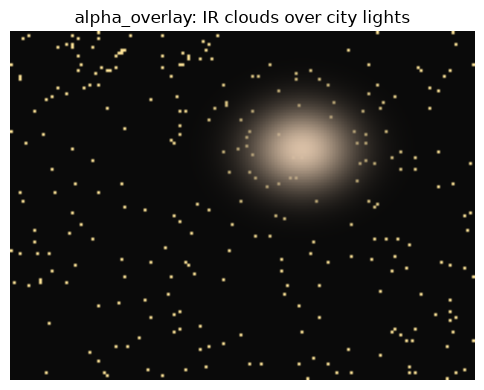

In [11]:
night = alpha_overlay(clouds, background.read_array())
print("night image shape:", night.shape)
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.imshow(np.moveaxis(np.clip(night, 0, 1), 0, -1))
ax.set_title("alpha_overlay: IR clouds over city lights")
ax.axis("off")
fig.tight_layout()

## `day_night_blend` — cross-fade by geometry

`day_night_blend(day, night, sza)` mixes the two images with the `day_weight` ramp:
`day * weight + night * (1 - weight)`. The sunlit side shows `true_color`, the dark side
shows the clouds-over-lights night image, and the terminator is a smooth blend.

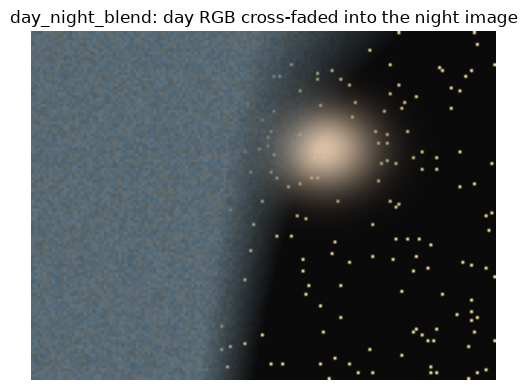

In [12]:
blended = day_night_blend(day, night, sza)
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(np.moveaxis(np.clip(blended, 0, 1), 0, -1))
ax.set_title("day_night_blend: day RGB cross-faded into the night image")
ax.axis("off")
fig.tight_layout()

## `true_color_with_night_ir` — the whole chain in one call

`true_color_with_night_ir(day, night_ir_rgba, background, sza)` wires the last three
steps together: overlay the clouds on the background, then blend against the day image by
SZA. It reproduces the blended figure above from the primitive inputs.

matches the manual blend: True


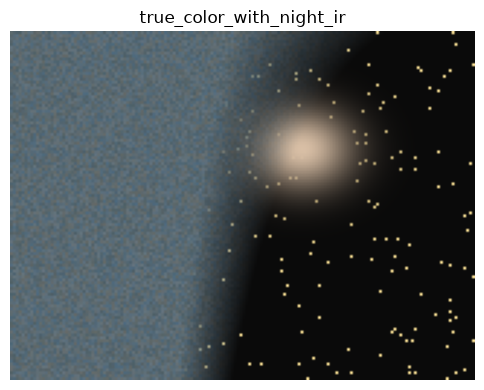

In [13]:
frame = true_color_with_night_ir(day, clouds, background.read_array(), sza)
print("matches the manual blend:", bool(np.allclose(frame, blended)))
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(np.moveaxis(np.clip(frame, 0, 1), 0, -1))
ax.set_title("true_color_with_night_ir")
ax.axis("off")
fig.tight_layout()

## Takeaway

- `solar_zenith_angle` gives the Sun's per-pixel geometry; `day_weight` turns it into a
  smooth `[0, 1]` twilight ramp.
- `true_color` builds the day RGB (synthetic green); `night_ir` builds the RGBA cloud
  image; `static_image` loads/warps the city-lights background.
- `alpha_overlay` composites clouds over lights, `day_night_blend` cross-fades day into
  night by SZA, and `true_color_with_night_ir` is the whole chain in one call.

Because the blend keys off geometry, not brightness, a dark daytime feature (an eclipse
umbra) still renders through the day path - see
[the eclipse notebook](eclipse_day_night.ipynb).